# Without dynamic weighting

Testing multiplier: 4.0
Testing multiplier: 5.6
Testing multiplier: 7.2
Testing multiplier: 8.8
Testing multiplier: 10.4
Testing multiplier: 12.0
Testing multiplier: 13.6
Testing multiplier: 15.2
Testing multiplier: 16.8
Testing multiplier: 18.4
Testing multiplier: 20.0
Testing multiplier: 21.6
Testing multiplier: 23.2
Testing multiplier: 24.8
Testing multiplier: 26.4
Testing multiplier: 28.0
Testing multiplier: 29.6
Testing multiplier: 31.2
Testing multiplier: 32.8
Testing multiplier: 34.4
Testing multiplier: 36.0
Testing multiplier: 37.6
Testing multiplier: 39.2
Testing multiplier: 40.8
Testing multiplier: 42.4
Testing multiplier: 44.0
Testing multiplier: 45.6
Testing multiplier: 47.2
Testing multiplier: 48.8
Testing multiplier: 50.4
Testing multiplier: 52.0
Testing multiplier: 53.6
Testing multiplier: 55.2
Testing multiplier: 56.8
Testing multiplier: 58.4
Testing multiplier: 60.0
Testing multiplier: 61.6
Testing multiplier: 63.2
Testing multiplier: 64.8
Testing multiplier: 66.4
Test

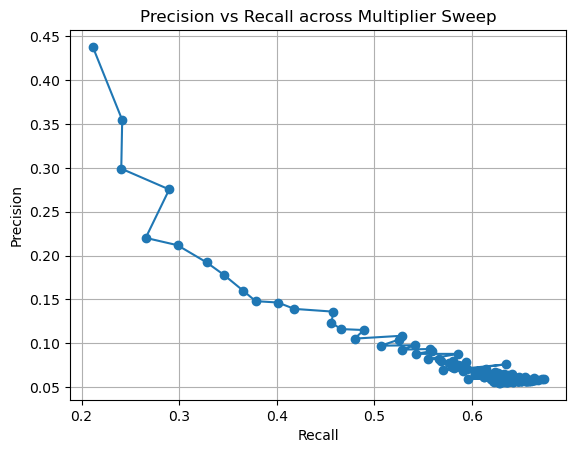

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score

# ------------------------------
# Load Data
# ------------------------------
data = pd.read_csv("C:/Users/aiden/School/6380/in-silico-drug-discovery/data/input_data.csv")
labeled = data[data["senolytic"].isin([0,1])].copy()

X = labeled.drop(columns=["senolytic","ID"])
y = labeled["senolytic"].values


# ------------------------------
# Pipeline Function
# ------------------------------
def run_pipeline(multiplier):

    skf = StratifiedKFold(n_splits=5, shuffle=True)

    precision_scores, recall_scores = [], []

    for train_idx, test_idx in skf.split(X, y):

        train_df = labeled.iloc[train_idx]
        test_df = labeled.iloc[test_idx]

        feature_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols.remove("senolytic")

        X_train = train_df[feature_cols].values
        X_test = test_df[feature_cols].values
        y_train = train_df["senolytic"].values.astype(int)
        y_test = test_df["senolytic"].values.astype(int)

        # Variance filter
        variances = np.var(X_train, axis=0)
        keep_var = variances > 1e-6
        X_train = X_train[:, keep_var]
        X_test = X_test[:, keep_var]

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # PCA
        pca = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)

        X_full_pca = np.vstack([X_train_pca, X_test_pca])
        X_full_scaled = np.vstack([X_train_scaled, X_test_scaled])

        # KNN
        k = 50
        knn = NearestNeighbors(n_neighbors=k, metric="cosine")
        knn.fit(X_train_pca)

        distances, indices = knn.kneighbors(X_full_pca)

        local_probs = []

        for i in range(len(X_full_pca)):

            neighbor_idx = indices[i]
            dists = distances[i]

            X_neighbors = X_train_scaled[neighbor_idx]
            y_neighbors = y_train[neighbor_idx]

            pos_count = np.sum(y_neighbors == 1)
            neg_count = np.sum(y_neighbors == 0)

            # Edge cases
            if pos_count <= 1 and neg_count > 2:
                local_probs.append(0.02)
                continue
            if neg_count <= 1 and pos_count > 2:
                local_probs.append(0.98)
                continue
            if pos_count == 0:
                local_probs.append(0.0)
                continue
            if neg_count == 0:
                local_probs.append(1.0)
                continue

            # Imbalance weighting
            ratio = neg_count / (pos_count + 1e-8)

            if ratio >= 1:
                w_pos = multiplier
                w_neg = 1.0
            else:
                w_pos = 1.0
                w_neg = 1.1

            scale = (w_pos + w_neg) / 2
            w_pos /= scale
            w_neg /= scale

            # Distance weights
            sigma = np.mean(dists) + 1e-8
            weights = np.exp(-(dists**2) / (2 * sigma**2))

            if np.sum(weights) == 0:
                weights = np.ones_like(weights)

            sample_weights = weights.copy()
            sample_weights[y_neighbors == 1] *= w_pos
            sample_weights[y_neighbors == 0] *= w_neg

            model = LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=5000
            )

            model.fit(X_neighbors, y_neighbors, sample_weight=sample_weights)

            prob = model.predict_proba(
                X_full_scaled[i].reshape(1, -1)
            )[0,1]

            local_probs.append(prob)

        local_probs = np.array(local_probs)

        test_probs = local_probs[len(X_train):]
        y_pred = (test_probs >= 0.5).astype(int)

        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))

    return np.mean(precision_scores), np.mean(recall_scores)


# ------------------------------
# Sweep multipliers
# ------------------------------
multipliers = np.arange(4.0, 320, 1.6)

avg_precisions = []
avg_recalls = []

for m in multipliers:
    print(f"Testing multiplier: {m:.1f}")

    run_precisions = []
    run_recalls = []

    for _ in range(5):
        p, r = run_pipeline(m)
        run_precisions.append(p)
        run_recalls.append(r)

    avg_precisions.append(np.mean(run_precisions))
    avg_recalls.append(np.mean(run_recalls))


# ------------------------------
# Plot Precision vs Recall
# ------------------------------
plt.figure()
plt.plot(avg_recalls, avg_precisions, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()
plt.show()

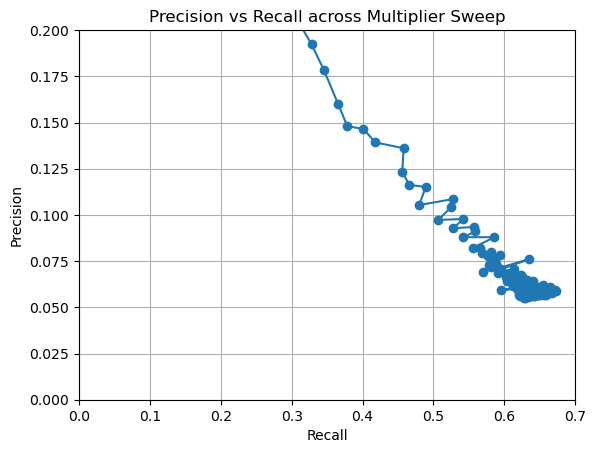

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

PDF saved to precision_recall_report.pdf
CSV saved: precision_recall_results.csv


In [2]:
plt.figure()
plt.plot(avg_recalls, avg_precisions, marker='o')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()

# CUSTOM AXIS LIMITS
plt.xlim(0, 0.7)   # cut off right side at 0.7
plt.ylim(0, 0.2)   # cut off top at 0.2

# SAVE IMAGE
plot_path = "precision_recall_plot.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()

# SAVE IMAGE
plot_path = "precision_recall_plot.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()
# SAVE IMAGE
plot_path = "precision_recall_plot.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()
results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls
})

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "precision_recall_report.pdf"

doc = SimpleDocTemplate(pdf_path)
styles = getSampleStyleSheet()

elements = []

# Title
elements.append(Paragraph("Precision vs Recall Analysis", styles["Title"]))
elements.append(Spacer(1, 12))

# Add plot image
elements.append(Paragraph("Precision vs Recall Plot", styles["Heading2"]))
elements.append(Spacer(1, 10))
elements.append(Image(plot_path, width=400, height=300))
elements.append(Spacer(1, 20))

# Add table
elements.append(Paragraph("Results Table", styles["Heading2"]))
elements.append(Spacer(1, 10))

# Convert dataframe to table format
table_data = [results_df.columns.tolist()] + results_df.round(4).values.tolist()

table = Table(table_data)

# Optional styling
table.setStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.black)
])

elements.append(table)

# Build PDF
doc.build(elements)

print(f"PDF saved to {pdf_path}")

results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls
})

csv_path = "precision_recall_results.csv"
results_df.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)

# With dynamic weighting

Testing multiplier: 1.0
Testing multiplier: 2.6
Testing multiplier: 4.2
Testing multiplier: 5.8
Testing multiplier: 7.4
Testing multiplier: 9.0
Testing multiplier: 10.6
Testing multiplier: 12.2
Testing multiplier: 13.8
Testing multiplier: 15.4
Testing multiplier: 17.0
Testing multiplier: 18.6
Testing multiplier: 20.2
Testing multiplier: 21.8
Testing multiplier: 23.4
Testing multiplier: 25.0
Testing multiplier: 26.6
Testing multiplier: 28.2
Testing multiplier: 29.8
Testing multiplier: 31.4
Testing multiplier: 33.0
Testing multiplier: 34.6
Testing multiplier: 36.2
Testing multiplier: 37.8
Testing multiplier: 39.4
Testing multiplier: 41.0
Testing multiplier: 42.6
Testing multiplier: 44.2
Testing multiplier: 45.8
Testing multiplier: 47.4
Testing multiplier: 49.0
Testing multiplier: 50.6
Testing multiplier: 52.2
Testing multiplier: 53.8
Testing multiplier: 55.4
Testing multiplier: 57.0
Testing multiplier: 58.6
Testing multiplier: 60.2
Testing multiplier: 61.8
Testing multiplier: 63.4
Testin

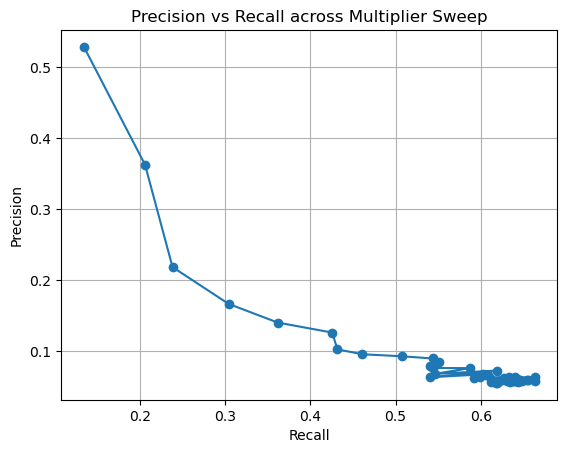

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score

# ------------------------------
# Load Data
# ------------------------------
data = pd.read_csv("C:/Users/aiden/School/6380/in-silico-drug-discovery/data/input_data.csv")
labeled = data[data["senolytic"].isin([0,1])].copy()

X = labeled.drop(columns=["senolytic","ID"])
y = labeled["senolytic"].values


# ------------------------------
# Pipeline Function
# ------------------------------
def run_pipeline(multiplier):

    skf = StratifiedKFold(n_splits=5, shuffle=True)

    precision_scores, recall_scores = [], []

    for train_idx, test_idx in skf.split(X, y):

        train_df = labeled.iloc[train_idx]
        test_df = labeled.iloc[test_idx]

        feature_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols.remove("senolytic")

        X_train = train_df[feature_cols].values
        X_test = test_df[feature_cols].values
        y_train = train_df["senolytic"].values.astype(int)
        y_test = test_df["senolytic"].values.astype(int)

        # Variance filter
        variances = np.var(X_train, axis=0)
        keep_var = variances > 1e-6
        X_train = X_train[:, keep_var]
        X_test = X_test[:, keep_var]

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # PCA
        pca = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)

        X_full_pca = np.vstack([X_train_pca, X_test_pca])
        X_full_scaled = np.vstack([X_train_scaled, X_test_scaled])

        # KNN
        k = 50
        knn = NearestNeighbors(n_neighbors=k, metric="cosine")
        knn.fit(X_train_pca)

        distances, indices = knn.kneighbors(X_full_pca)

        local_probs = []

        for i in range(len(X_full_pca)):

            neighbor_idx = indices[i]
            dists = distances[i]

            X_neighbors = X_train_scaled[neighbor_idx]
            y_neighbors = y_train[neighbor_idx]

            pos_count = np.sum(y_neighbors == 1)
            neg_count = np.sum(y_neighbors == 0)

            # Edge cases
            if pos_count <= 1 and neg_count > 2:
                local_probs.append(0.02)
                continue
            if neg_count <= 1 and pos_count > 2:
                local_probs.append(0.98)
                continue
            if pos_count == 0:
                local_probs.append(0.0)
                continue
            if neg_count == 0:
                local_probs.append(1.0)
                continue

            # Imbalance weighting
            ratio = neg_count / (pos_count + 1e-8)

            if ratio >= 1:
                w_pos = multiplier * ratio/6
                w_neg = 1.0
            else:
                w_pos = 1.0
                inv_ratio = 1 / (ratio + 1e-8)
                w_neg = min(inv_ratio, 1.1)

            scale = (w_pos + w_neg) / 2
            w_pos /= scale
            w_neg /= scale

            # Distance weights
            sigma = np.mean(dists) + 1e-8
            weights = np.exp(-(dists**2) / (2 * sigma**2))

            if np.sum(weights) == 0:
                weights = np.ones_like(weights)

            sample_weights = weights.copy()
            sample_weights[y_neighbors == 1] *= w_pos
            sample_weights[y_neighbors == 0] *= w_neg

            model = LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=5000
            )

            model.fit(X_neighbors, y_neighbors, sample_weight=sample_weights)

            prob = model.predict_proba(
                X_full_scaled[i].reshape(1, -1)
            )[0,1]

            local_probs.append(prob)

        local_probs = np.array(local_probs)

        test_probs = local_probs[len(X_train):]
        y_pred = (test_probs >= 0.5).astype(int)

        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))

    return np.mean(precision_scores), np.mean(recall_scores)


# ------------------------------
# Sweep multipliers
# ------------------------------
multipliers = np.arange(1.0, 80, 1.6)

avg_precisions = []
avg_recalls = []

for m in multipliers:
    print(f"Testing multiplier: {m:.1f}")

    run_precisions = []
    run_recalls = []

    for _ in range(4):
        p, r = run_pipeline(m)
        run_precisions.append(p)
        run_recalls.append(r)

    avg_precisions.append(np.mean(run_precisions))
    avg_recalls.append(np.mean(run_recalls))


# ------------------------------
# Plot Precision vs Recall
# ------------------------------
plt.figure()
plt.plot(avg_recalls, avg_precisions, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()
plt.show()

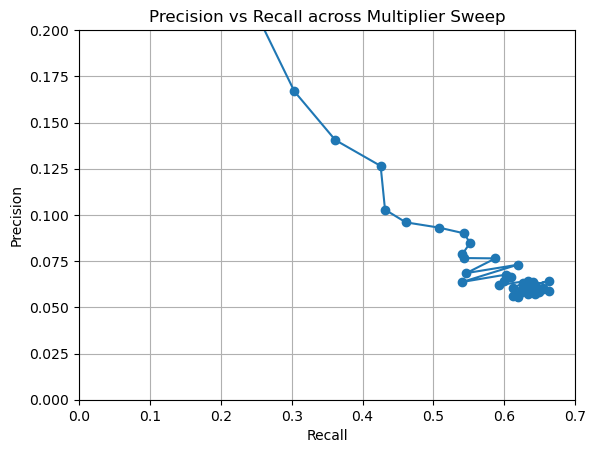

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

PDF saved to precision_recall_report_w_dynamic_weight.pdf
CSV saved: precision_recall_results_w_dynamic_weight.csv


In [4]:
plt.figure()
plt.plot(avg_recalls, avg_precisions, marker='o')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()

# CUSTOM AXIS LIMITS
plt.xlim(0, 0.7)   # cut off right side at 0.7
plt.ylim(0, 0.2)   # cut off top at 0.2

# SAVE IMAGE
plot_path = "precision_recall_plot_w_dynamic_weight.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()

# SAVE IMAGE
plot_path = "precision_recall_plot_w_dynamic_weight.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()
# SAVE IMAGE
plot_path = "precision_recall_plot_w_dynamic_weight.png"
plt.savefig(plot_path, bbox_inches='tight')

plt.show()
results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls
})

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

pdf_path = "precision_recall_report_w_dynamic_weight.pdf"

doc = SimpleDocTemplate(pdf_path)
styles = getSampleStyleSheet()

elements = []

# Title
elements.append(Paragraph("Precision vs Recall Analysis", styles["Title"]))
elements.append(Spacer(1, 12))

# Add plot image
elements.append(Paragraph("Precision vs Recall Plot", styles["Heading2"]))
elements.append(Spacer(1, 10))
elements.append(Image(plot_path, width=400, height=300))
elements.append(Spacer(1, 20))

# Add table
elements.append(Paragraph("Results Table", styles["Heading2"]))
elements.append(Spacer(1, 10))

# Convert dataframe to table format
table_data = [results_df.columns.tolist()] + results_df.round(4).values.tolist()

table = Table(table_data)

# Optional styling
table.setStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.black)
])

elements.append(table)

# Build PDF
doc.build(elements)

print(f"PDF saved to {pdf_path}")

results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls
})

csv_path = "precision_recall_results_w_dynamic_weight.csv"
results_df.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)

# LOOCV


=== Multiplier 1.0 ===


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    3.2s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    4.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    5.0s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    5.2s
[Parallel(n_jobs=16)]: Done 233 tasks      | elapsed:  


=== Multiplier 2.6 ===


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.19719815254211426s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 100 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 160 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 194 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 266 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done 304 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done 346 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]


=== Multiplier 4.2 ===


...

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.1934511661529541s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 100 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 160 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 194 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 266 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done 304 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 346 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]:


=== Multiplier 15.4 ===


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.18674230575561523s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 100 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 160 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 194 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 266 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done 304 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 346 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]


=== Multiplier 17.0 ===


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.18802189826965332s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 100 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 160 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 194 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 228 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 266 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done 304 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 346 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]

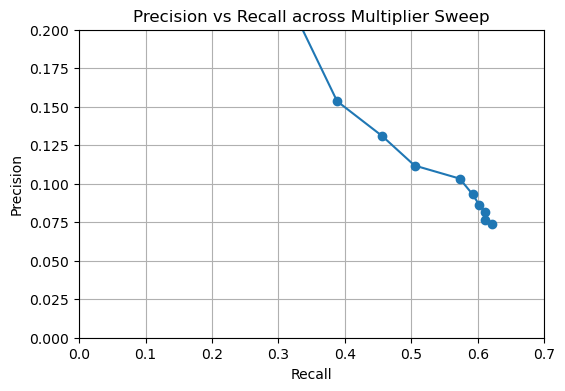

CSV saved: precision_recall_results_w_dynamic_weight.csv
PDF saved to precision_recall_report_w_dynamic_weight.pdf


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, accuracy_score, confusion_matrix
from joblib import Parallel, delayed
import multiprocessing
import matplotlib.pyplot as plt
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# ------------------------------
# Load Data
# ------------------------------
data = pd.read_csv("C:/Users/aiden/School/6380/in-silico-drug-discovery/data/input_data.csv")
labeled = data[data["senolytic"].isin([0,1])].copy()

X = labeled.drop(columns=["senolytic","ID","SMILES"])
y = labeled["senolytic"].values

# ------------------------------
# Single fold processing
# ------------------------------
def process_fold(train_idx, test_idx, X, y, multiplier):
    X_train = X.iloc[train_idx].values.astype(np.float64)
    X_test = X.iloc[test_idx].values.astype(np.float64).reshape(1, -1)
    y_train = y[train_idx].astype(np.int64)
    y_test = int(y[test_idx])

    # Variance filter
    variances = np.var(X_train, axis=0)
    keep_var = variances > 1e-6
    X_train = X_train[:, keep_var]
    X_test = X_test[:, keep_var]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # KNN neighborhood
    k = min(50, len(X_train))
    knn = NearestNeighbors(n_neighbors=k, metric="cosine")
    knn.fit(X_train_pca)
    distances, indices = knn.kneighbors(X_test_pca)

    neighbor_idx = indices[0]
    dists = distances[0]

    X_neighbors = X_train_scaled[neighbor_idx]
    y_neighbors = y_train[neighbor_idx]

    pos_count = int(np.sum(y_neighbors == 1))
    neg_count = int(np.sum(y_neighbors == 0))

    # ------------------------
    # Fallback / weighting logic
    # ------------------------
    if pos_count <= 1 and neg_count > 2:
        prob = 0.02
    elif neg_count <= 1 and pos_count > 2:
        prob = 0.98
    elif pos_count == 0:
        prob = 0.0
    elif neg_count == 0:
        prob = 1.0
    else:
        ratio = neg_count / (pos_count + 1e-8)
        if ratio >= 1:
            w_pos = multiplier * min(ratio, 4)
            w_neg = 1.0
        else:
            inv_ratio = 1 / (ratio + 1e-8)
            w_neg = min(inv_ratio, 1.1)
            w_pos = multiplier

        scale = (w_pos + w_neg) / 2
        w_pos /= scale
        w_neg /= scale

        sigma = np.mean(dists) + 1e-8
        weights = np.exp(-(dists**2) / (2 * sigma**2))
        if np.sum(weights) == 0:
            weights = np.ones_like(weights)

        sample_weights = weights.copy()
        sample_weights[y_neighbors == 1] *= w_pos
        sample_weights[y_neighbors == 0] *= w_neg

        model = LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000)
        model.fit(X_neighbors, y_neighbors, sample_weight=sample_weights)
        prob = model.predict_proba(X_test_scaled)[0, 1]

    pred = int(prob >= 0.5)
    return {"true": y_test, "pred": pred, "prob": prob}

# ------------------------------
# Parallel LOOCV runner
# ------------------------------
def run_loocv_parallel_multiplier(X, y, multiplier, n_jobs=-1):
    loo = LeaveOneOut()
    splits = list(loo.split(X, y))

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_fold)(train_idx, test_idx, X, y, multiplier)
        for train_idx, test_idx in splits
    )

    df_results = pd.DataFrame(results)

    y_true = df_results["true"].values
    y_pred = df_results["pred"].values
    y_prob = df_results["prob"].values

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    return precision, recall, auc

# ------------------------------
# Multiplier sweep
# ------------------------------
multipliers = np.arange(1.0, 17.6, 1.6)
avg_precisions, avg_recalls, avg_aucs = [], [], []

for m in multipliers:
    print(f"\n=== Multiplier {m:.1f} ===")
    run_precisions, run_recalls, run_aucs = [], [], []

    # Run 4 repeats per multiplier
    for _ in range(4):
        p, r, auc = run_loocv_parallel_multiplier(X, y, m, n_jobs=multiprocessing.cpu_count())
        run_precisions.append(p)
        run_recalls.append(r)
        run_aucs.append(auc)

    avg_precisions.append(np.mean(run_precisions))
    avg_recalls.append(np.mean(run_recalls))
    avg_aucs.append(np.mean(run_aucs))

# ------------------------------
# Plot Precision vs Recall
# ------------------------------
plt.figure(figsize=(6,4))
plt.plot(avg_recalls, avg_precisions, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()
plt.xlim(0, 0.7)
plt.ylim(0, 0.2)
plot_path = "precision_recall_plot_w_dynamic_weight.png"
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

# ------------------------------
# Save results to CSV
# ------------------------------
results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls,
    "AUC": avg_aucs
})
csv_path = "precision_recall_results_w_dynamic_weight.csv"
results_df.to_csv(csv_path, index=False)
print("CSV saved:", csv_path)

# ------------------------------
# Save PDF report
# ------------------------------
pdf_path = "precision_recall_report_w_dynamic_weight.pdf"
doc = SimpleDocTemplate(pdf_path)
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("Precision vs Recall Analysis", styles["Title"]))
elements.append(Spacer(1, 12))
elements.append(Paragraph("Precision vs Recall Plot", styles["Heading2"]))
elements.append(Spacer(1, 10))
elements.append(Image(plot_path, width=400, height=300))
elements.append(Spacer(1, 20))
elements.append(Paragraph("Results Table", styles["Heading2"]))
elements.append(Spacer(1, 10))

table_data = [results_df.columns.tolist()] + results_df.round(4).values.tolist()
table = Table(table_data)
table.setStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.black)
])
elements.append(table)
doc.build(elements)
print(f"PDF saved to {pdf_path}")

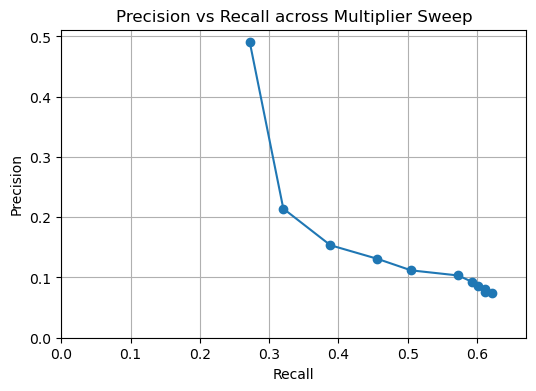

CSV saved: precision_recall_results_w_dynamic_weight.csv
PDF saved to precision_recall_report_w_dynamic_weight.pdf


In [9]:
# ------------------------------
# Dynamic Plot Precision vs Recall
# ------------------------------
plt.figure(figsize=(6, 4))
plt.plot(avg_recalls, avg_precisions, marker='o', linestyle='-')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall across Multiplier Sweep")
plt.grid()

# Dynamic axis limits with a small margin
x_margin = 0.05
y_margin = 0.02
plt.xlim(0, min(1.0, max(avg_recalls) + x_margin))
plt.ylim(0, min(1.0, max(avg_precisions) + y_margin))

plot_path = "precision_recall_plot_w_dynamic_weight.png"
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

# ------------------------------
# Save results to CSV
# ------------------------------
results_df = pd.DataFrame({
    "Multiplier": multipliers,
    "Precision": avg_precisions,
    "Recall": avg_recalls,
    "AUC": avg_aucs
})
csv_path = "precision_recall_results_w_dynamic_weight.csv"
results_df.to_csv(csv_path, index=False)
print("CSV saved:", csv_path)

# ------------------------------
# Save PDF report
# ------------------------------
pdf_path = "precision_recall_report_w_dynamic_weight.pdf"
doc = SimpleDocTemplate(pdf_path)
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("Precision vs Recall Analysis", styles["Title"]))
elements.append(Spacer(1, 12))
elements.append(Paragraph("Precision vs Recall Plot", styles["Heading2"]))
elements.append(Spacer(1, 10))
elements.append(Image(plot_path, width=400, height=300))
elements.append(Spacer(1, 20))
elements.append(Paragraph("Results Table", styles["Heading2"]))
elements.append(Spacer(1, 10))

table_data = [results_df.columns.tolist()] + results_df.round(4).values.tolist()
table = Table(table_data)
table.setStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.black)
])
elements.append(table)
doc.build(elements)
print(f"PDF saved to {pdf_path}")